# Set Up and creation of SparkDFs


## Setup

In [35]:
from pyspark.sql import SparkSession
import pymongo
import matplotlib.pyplot as plt

# Init Spark session
spark = SparkSession.builder.appName("NetflixAnalysis").getOrCreate()

# Connect to MongoDB and fetch data
client = pymongo.MongoClient("mongodb://localhost:27017/")
db = client["netflixDataset"]

In [36]:
# See list of Collections
list_of_collections = db.list_collection_names()
list_of_collections

['recommendation_logs',
 'watch_history',
 'users',
 'search_logs',
 'movies',
 'reviews']

In [37]:
# Convert all connections to SparkDF (excl _id)
collection = db["movies"]
data = list(collection.find())
data = [{k: v for k, v in doc.items() if k != "_id"} for doc in data]
df_movies = spark.createDataFrame(data)
print("df_movies created")

collection = db["recommendation_logs"]
data = list(collection.find())
data = [{k: v for k, v in doc.items() if k != "_id"} for doc in data]
df_recommendation_logs = spark.createDataFrame(data)
print("df_recommendation_logs created")

collection = db["reviews"]
data = list(collection.find())
data = [{k: v for k, v in doc.items() if k != "_id"} for doc in data]
df_reviews = spark.createDataFrame(data)
print("df_reviews created")

collection = db["search_logs"]
data = list(collection.find())
data = [{k: v for k, v in doc.items() if k != "_id"} for doc in data]
df_search_logs = spark.createDataFrame(data)
print("df_search_logs created")

collection = db["users"]
data = list(collection.find())
data = [{k: v for k, v in doc.items() if k != "_id"} for doc in data]
df_users = spark.createDataFrame(data)
print("df_users created")

collection = db["watch_history"]
data = list(collection.find())
data = [{k: v for k, v in doc.items() if k != "_id"} for doc in data]
df_watch_history = spark.createDataFrame(data)
print("df_watch_history created")

df_movies created
df_recommendation_logs created
df_reviews created
df_search_logs created
df_users created
df_watch_history created


## Print Creates Dataframes

In [38]:
df_movies.show(5, truncate=False)

+-------------------+---------------+---------------+-----------------+----------------+-------------+---------------+-------------------+--------+----------+------+------------+---------------+-----------+-----------------+------------------+------------------+-----------------+
|added_to_platform  |content_type   |content_warning|country_of_origin|duration_minutes|genre_primary|genre_secondary|is_netflix_original|language|movie_id  |rating|release_year|title          |imdb_rating|production_budget|box_office_revenue|number_of_episodes|number_of_seasons|
+-------------------+---------------+---------------+-----------------+----------------+-------------+---------------+-------------------+--------+----------+------+------------+---------------+-----------+-----------------+------------------+------------------+-----------------+
|2023-08-07 00:00:00|Stand-up Comedy|false          |Japan            |35.0            |History      |Thriller       |false              |French  |movie_0001

In [39]:
df_recommendation_logs.show(5, truncate=False)

+-----------------+-----------+----------+----------------+-------------------+-----------------+-------------------+-----------+----------+-----------+--------------------+
|algorithm_version|device_type|movie_id  |position_in_list|recommendation_date|recommendation_id|recommendation_type|time_of_day|user_id   |was_clicked|recommendation_score|
+-----------------+-----------+----------+----------------+-------------------+-----------------+-------------------+-----------+----------+-----------+--------------------+
|v1.4             |Tablet     |movie_0771|10              |2025-07-03 00:00:00|rec_000001       |new_releases       |evening    |user_06326|false      |NULL                |
|v1.4             |Mobile     |movie_0985|9               |2024-11-07 00:00:00|rec_000002       |genre_based        |evening    |user_02180|false      |0.916               |
|v1.4             |Tablet     |movie_0834|2               |2024-08-22 00:00:00|rec_000003       |personalized       |evening    |u

In [40]:
df_reviews.show(5, truncate=False)

+-----------+-------------+-----------------+----------+------+-------------------+-------------+-----------------------------------------------------------+---------+---------------+-----------+----------+
|device_type|helpful_votes|is_verified_watch|movie_id  |rating|review_date        |review_id    |review_text                                                |sentiment|sentiment_score|total_votes|user_id   |
+-----------+-------------+-----------------+----------+------+-------------------+-------------+-----------------------------------------------------------+---------+---------------+-----------+----------+
|Mobile     |3.0          |false            |movie_0360|4     |2025-03-29 00:00:00|review_000001|Fantastic cinematography and plot twists.                  |positive |0.711          |5.0        |user_07066|
|Mobile     |2.0          |true             |movie_0095|5     |2024-07-19 00:00:00|review_000002|This series is a masterpiece!                              |positive |0.645

In [41]:
df_search_logs.show(5, truncate=False)

+-----------------------+-----------+--------+----------------+----------------+-------------------+-----------------------+-------------+----------------------------+------------+----------+
|clicked_result_position|device_type|had_typo|location_country|results_returned|search_date        |search_duration_seconds|search_id    |search_query                |used_filters|user_id   |
+-----------------------+-----------+--------+----------------+----------------+-------------------+-----------------------+-------------+----------------------------+------------+----------+
|2                      |Tablet     |false   |Canada          |20              |2024-03-22 00:00:00|12.4                   |search_000001|classic movies              |false       |user_09864|
|4                      |Tablet     |true    |USA             |24              |2025-11-22 00:00:00|63.5                   |search_000002|stand up comedy             |false       |user_08038|
|1                      |Tablet     |tru

In [42]:
df_users.show(5, truncate=False)

+----+------------------+-------+--------------------------+-------------------------+----------+------+--------------+---------+---------+-------------+--------------+--------------+-----------------+-----------------------+----------+
|age |city              |country|created_at                |email                    |first_name|gender|household_size|is_active|last_name|monthly_spend|primary_device|state_province|subscription_plan|subscription_start_date|user_id   |
+----+------------------+-------+--------------------------+-------------------------+----------+------+--------------+---------+---------+-------------+--------------+--------------+-----------------+-----------------------+----------+
|43.0|North Jefferyhaven|USA    |2023-04-01 14:40:50.540242|figueroajohn@example.org |Erica     |Male  |1.0           |true     |Garza    |36.06        |Laptop        |Massachusetts |Basic            |2024-04-08 00:00:00    |user_00001|
|38.0|North Noahstad    |USA    |2024-10-10 15:39:11

In [43]:
df_watch_history.show(5, truncate=False)

+---------+-----------+-----------+----------------+----------+-------------------+-------+--------------+----------+-------------------+----------------------+-----------+
|action   |device_type|is_download|location_country|movie_id  |progress_percentage|quality|session_id    |user_id   |watch_date         |watch_duration_minutes|user_rating|
+---------+-----------+-----------+----------------+----------+-------------------+-------+--------------+----------+-------------------+----------------------+-----------+
|completed|Tablet     |false      |USA             |movie_0511|34.6               |HD     |session_000001|user_07271|2025-11-13 00:00:00|63.9                  |NULL       |
|started  |Laptop     |false      |USA             |movie_0588|44.2               |HD     |session_000002|user_00861|2025-02-26 00:00:00|120.1                 |NULL       |
|started  |Desktop    |false      |Canada          |movie_0694|84.7               |HD     |session_000003|user_05391|2024-12-15 00:00:0

In [44]:
df_recommendation_logs.cache()

DataFrame[algorithm_version: string, device_type: string, movie_id: string, position_in_list: bigint, recommendation_date: timestamp, recommendation_id: string, recommendation_type: string, time_of_day: string, user_id: string, was_clicked: boolean, recommendation_score: double]

# Analysis

## Comparing the clicktrough rate of different Algorithm versions

In [45]:
# Create Temp View for SQL Queries
df_recommendation_logs.createOrReplaceTempView("recommendations")

# Query: Count cases 'clicked' and 'not_clicked'. Calculate % of clicks. Order by algorithm version.
ctr_query = """
            SELECT
                algorithm_version,
                COUNT(*) AS total,
                SUM(CASE WHEN was_clicked = TRUE THEN 1 ELSE 0 END) AS clicked,
                SUM(CASE WHEN was_clicked = FALSE THEN 1 ELSE 0 END) AS not_clicked,
                ROUND(
                    SUM(CASE WHEN was_clicked = TRUE THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
                    2
                ) AS pct_clicked
            FROM
                recommendations
            GROUP BY
                algorithm_version
            ORDER BY
                algorithm_version;
          """

# Explain the plan
spark.sql(ctr_query).explain(True)

# Create pandas DataFrame for further processing and graphing
pd_ctr = spark.sql(ctr_query).toPandas()

pd_ctr


== Parsed Logical Plan ==
'Sort ['algorithm_version ASC NULLS FIRST], true
+- 'Aggregate ['algorithm_version], ['algorithm_version, 'COUNT(1) AS total#2174, 'SUM(CASE WHEN ('was_clicked = true) THEN 1 ELSE 0 END) AS clicked#2175, 'SUM(CASE WHEN ('was_clicked = false) THEN 1 ELSE 0 END) AS not_clicked#2176, 'ROUND((('SUM(CASE WHEN ('was_clicked = true) THEN 1 ELSE 0 END) * 100.0) / 'COUNT(1)), 2) AS pct_clicked#2177]
   +- 'UnresolvedRelation [recommendations], [], false

== Analyzed Logical Plan ==
algorithm_version: string, total: bigint, clicked: bigint, not_clicked: bigint, pct_clicked: decimal(27,2)
Sort [algorithm_version#1811 ASC NULLS FIRST], true
+- Aggregate [algorithm_version#1811], [algorithm_version#1811, count(1) AS total#2174L, sum(CASE WHEN (was_clicked#1820 = true) THEN 1 ELSE 0 END) AS clicked#2175L, sum(CASE WHEN (was_clicked#1820 = false) THEN 1 ELSE 0 END) AS not_clicked#2176L, round(((cast(sum(CASE WHEN (was_clicked#1820 = true) THEN 1 ELSE 0 END) as decimal(20,0))

,algorithm_version,total,clicked,not_clicked,pct_clicked
0,NaN,2620,410,2210,15.65
1,v1.2,5061,765,4296,15.12
2,v1.3,14756,2245,12511,15.21
3,v1.4,19632,2968,16664,15.12
4,v2.0,9931,1468,8463,14.78


In [46]:
# Remove Nulls from the DF
pd_ctr = pd_ctr.dropna(subset=["algorithm_version"])
# pd_ctr

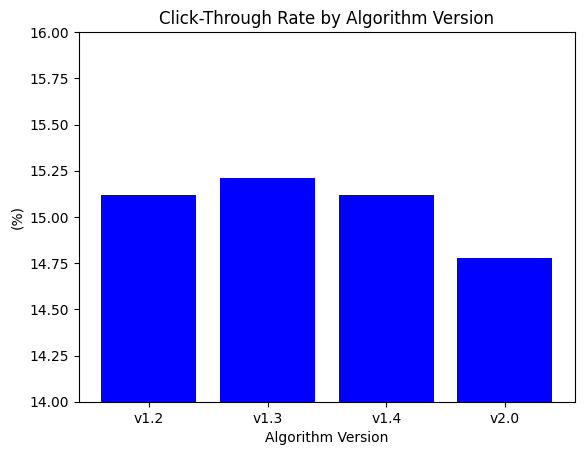

In [47]:
# Create a bar graph of the CTR per algorithm Version
plt.bar(pd_ctr["algorithm_version"], pd_ctr["pct_clicked"], color='blue')
plt.title('Click-Through Rate by Algorithm Version')
plt.ylim(14, 16) # Limit y axis for better visibility
plt.xlabel("Algorithm Version")
plt.ylabel("(%)")
plt.show()

## Watch Traffic per month

In [48]:
# Create Temp View for SQL Queries
df_watch_history.createOrReplaceTempView("watch_history")

# Query: Count watch traffic by date and order by date
watch_query = """
            SELECT watch_date,
            COUNT(*) AS watch_count
            FROM watch_history
            GROUP BY watch_date
            ORDER BY watch_date;
          """

# Explain the plan
spark.sql(watch_query).explain(True)

# Create pandas DataFrame for further processing and graphing
pd_watch_traffic = spark.sql(watch_query).toPandas()

pd_watch_traffic

== Parsed Logical Plan ==
'Sort ['watch_date ASC NULLS FIRST], true
+- 'Aggregate ['watch_date], ['watch_date, 'COUNT(1) AS watch_count#2654]
   +- 'UnresolvedRelation [watch_history], [], false

== Analyzed Logical Plan ==
watch_date: timestamp, watch_count: bigint
Sort [watch_date#1870 ASC NULLS FIRST], true
+- Aggregate [watch_date#1870], [watch_date#1870, count(1) AS watch_count#2654L]
   +- SubqueryAlias watch_history
      +- View (`watch_history`, [action#1861, device_type#1862, is_download#1863, location_country#1864, movie_id#1865, progress_percentage#1866, quality#1867, session_id#1868, user_id#1869, watch_date#1870, watch_duration_minutes#1871, user_rating#1872L])
         +- LogicalRDD [action#1861, device_type#1862, is_download#1863, location_country#1864, movie_id#1865, progress_percentage#1866, quality#1867, session_id#1868, user_id#1869, watch_date#1870, watch_duration_minutes#1871, user_rating#1872L], false

== Optimized Logical Plan ==
Sort [watch_date#1870 ASC NULLS 

,watch_date,watch_count
0,2024-01-01,139
1,2024-01-02,176
2,2024-01-03,144
3,2024-01-04,124
4,2024-01-05,135
...,...,...
726,2025-12-27,144
727,2025-12-28,127
728,2025-12-29,171
729,2025-12-30,136


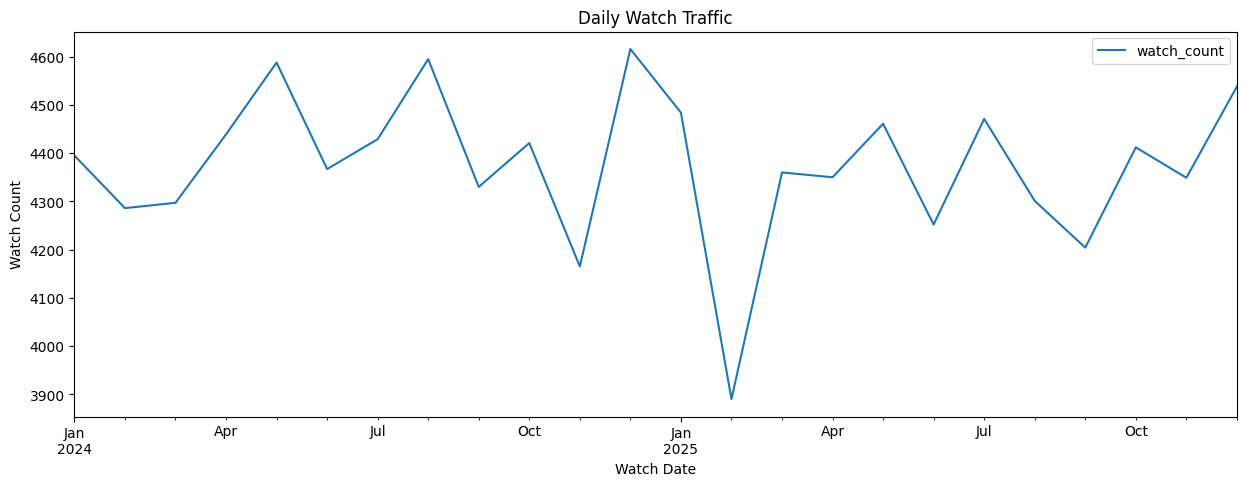

In [ ]:
# Create lineplot and resample to a monthly view
pd_watch_traffic.set_index("watch_date").resample("MS").sum().plot(figsize=(15,5))
plt.title('Monthly Watch Traffic')
plt.xlabel("Watch Date")
plt.ylabel("Watch Count")
plt.show()